In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import pandas as pd
%matplotlib inline

In [3]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=42)

In [4]:
X

array([[-6.59633932, -7.13901457],
       [-6.13753182, -6.58081701],
       [ 5.19820575,  2.04917508],
       ...,
       [ 3.69047995,  4.60555175],
       [ 4.03036663,  1.78619838],
       [-7.44179522, -7.08933147]], shape=(1000, 2))

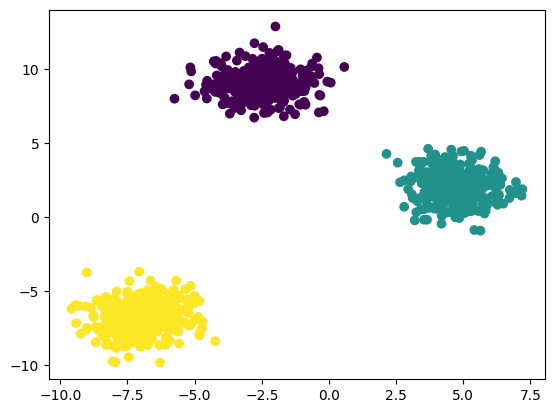

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans

In [10]:
# Elbow Method To Select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++',random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [11]:
wcss

[1600.000000000001,
 508.7488689892825,
 51.75322236627201,
 44.281672935224606,
 37.39534263702314,
 31.16433951930383,
 28.576232717525656,
 30.440636018543383,
 24.24102381486793,
 22.867707558554354]

Text(0, 0.5, 'WCSS')

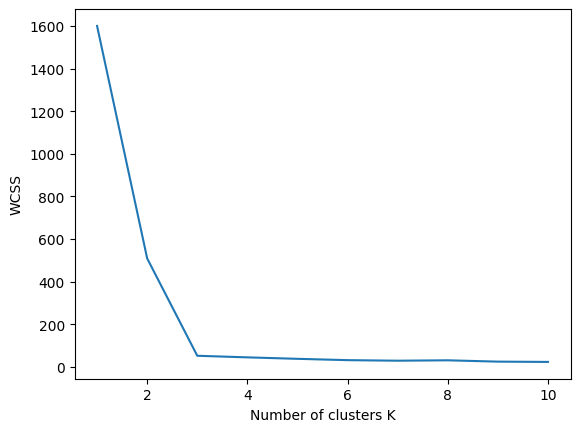

In [12]:
# Plot Elbow Curve
plt.plot(range(1,11),wcss)
plt.xlabel('Number of clusters K')
plt.ylabel('WCSS')

In [13]:
kmeans=KMeans(n_clusters=3,init='k-means++',random_state=42)

In [14]:
kmeans.fit_predict(X_train_scaled)

array([2, 1, 2, 2, 1, 1, 1, 2, 0, 1, 1, 1, 0, 2, 0, 2, 2, 1, 0, 2, 2, 2,
       0, 2, 0, 2, 0, 1, 1, 1, 1, 2, 2, 0, 1, 0, 0, 2, 2, 0, 1, 2, 0, 0,
       0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 0, 0, 2, 1, 2, 1, 0,
       2, 0, 0, 2, 1, 2, 0, 2, 2, 2, 2, 1, 1, 2, 2, 0, 2, 0, 0, 2, 0, 0,
       2, 2, 2, 1, 1, 2, 2, 2, 0, 2, 2, 2, 0, 0, 0, 1, 2, 2, 0, 0, 2, 2,
       2, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 1, 1, 2, 1, 0, 0, 2, 0,
       2, 1, 0, 2, 2, 1, 2, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 2, 1, 0, 1,
       1, 2, 0, 1, 1, 0, 1, 0, 0, 0, 1, 2, 1, 2, 2, 0, 0, 0, 1, 2, 2, 1,
       2, 2, 1, 0, 0, 1, 0, 2, 0, 1, 0, 2, 1, 2, 0, 2, 2, 2, 2, 1, 0, 0,
       0, 2, 2, 0, 0, 2, 1, 1, 2, 0, 1, 2, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1,
       1, 0, 2, 1, 1, 0, 1, 1, 0, 2, 1, 2, 1, 2, 0, 1, 1, 0, 0, 2, 1, 0,
       1, 0, 1, 0, 1, 2, 2, 1, 1, 2, 1, 2, 2, 1, 2, 1, 2, 0, 2, 2, 1, 2,
       2, 0, 1, 1, 1, 0, 0, 2, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 2, 2, 2, 2, 0, 2, 2, 2, 1, 0, 0, 0, 2,

In [15]:
y_pred=kmeans.predict(X_test_scaled)

In [16]:
# Validating the K Value
# 1. kneelocator
# 2. Silhouette Scoring

In [17]:
# Kneelocator Method
%pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [18]:
from kneed import KneeLocator

In [19]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [20]:
# Silhouette Scoring Method
from sklearn.metrics import silhouette_score

In [22]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [23]:
silhouette_coefficients

[0.6851973424700912,
 0.8424768202445475,
 0.6705916034211137,
 0.5033105793312713,
 0.3504521053619189,
 0.33850715407118076,
 0.3367301677604571,
 0.3281666897428755,
 0.338421667390527]

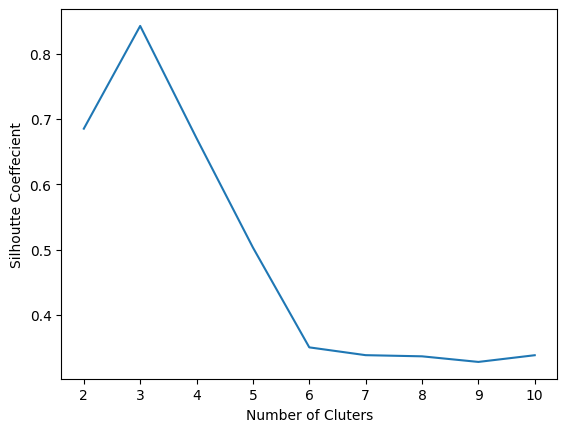

In [24]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()